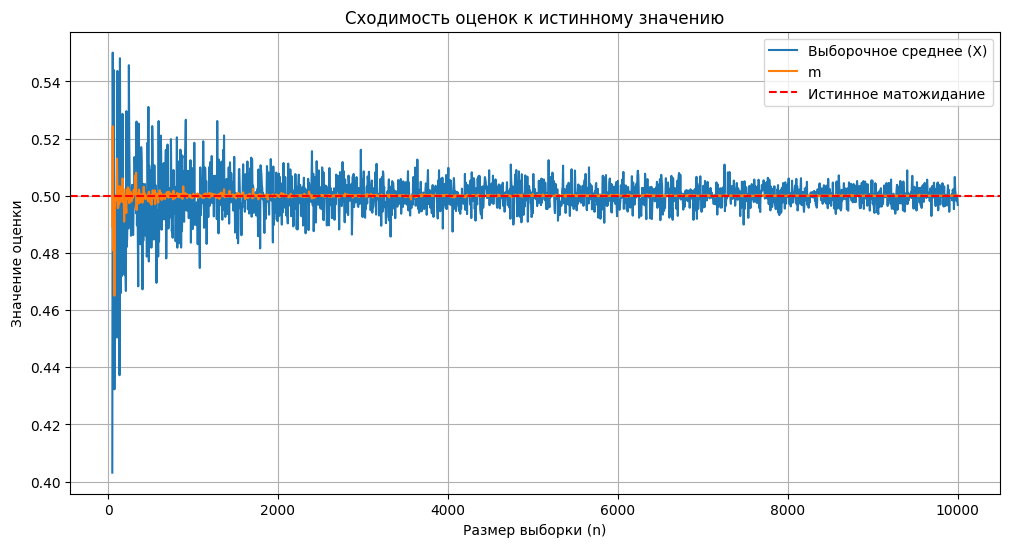

Дисперсия X: 0.00000836
Дисперсия m: 0.00000000
Среднее X (выборочное среднее): 0.50002
Среднее m (мин-макс оценка): 0.50000


<ipython-input-16-f1e9b76882f7>:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X_large, m_large], labels=['X', 'm'])


Text(0.5, 1.0, 'Сравнение разброса оценок (боксплоты)')

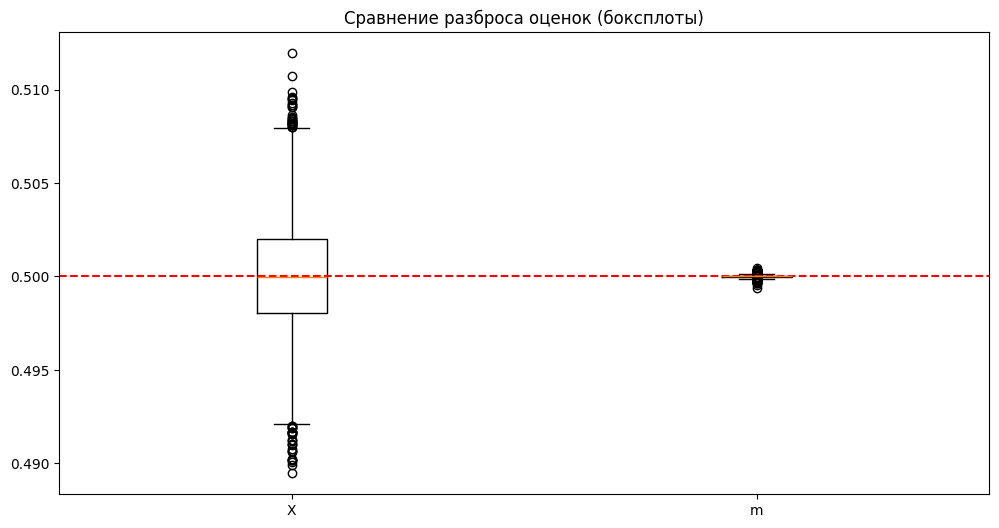

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Состоятельность оценок
n_values = np.arange(50, 10001, 5)  # от 50 до 10000 с шагом 5
X = []
m = []

for n in n_values:
    sample = np.random.uniform(0, 1, n)
    x_bar = np.mean(sample)
    x_min = np.min(sample)
    x_max = np.max(sample)
    m_hat = (x_min + x_max) / 2
    X.append(x_bar)
    m.append(m_hat)

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(n_values, X, label='Выборочное среднее (X)')
plt.plot(n_values, m, label='m')
plt.axhline(y=0.5, color='r', linestyle='--', label='Истинное матожидание')
plt.xlabel('Размер выборки (n)')
plt.ylabel('Значение оценки')
plt.title('Сходимость оценок к истинному значению')
plt.legend()
plt.grid(True)
plt.show()

# 2) Несмещенность (используем n=10000 и N=10000 выборок)
n = 10000
N = 10000
X_large = []
m_large = []

for _ in range(N):
    sample = np.random.uniform(0, 1, n)
    x_bar = np.mean(sample)  # Выборочное среднее
    x_min = np.min(sample)
    x_max = np.max(sample)
    m_hat = (x_min + x_max) / 2
    X_large.append(x_bar)
    m_large.append(m_hat)

# Средние значения
mean_X = np.mean(X_large)
mean_m = np.mean(m_large)
print(f"Дисперсия X: {np.var(X_large):.8f}")
print(f"Дисперсия m: {np.var(m_large):.8f}")

print(f"Среднее X (выборочное среднее): {mean_X:.5f}")
print(f"Среднее m (мин-макс оценка): {mean_m:.5f}")

# 3) Визуализация через boxplot и гистограммы
plt.figure(figsize=(12, 6))

# Боксплоты
plt.boxplot([X_large, m_large], labels=['X', 'm'])
plt.axhline(y=0.5, color='r', linestyle='--')
plt.title('Сравнение разброса оценок (боксплоты)')

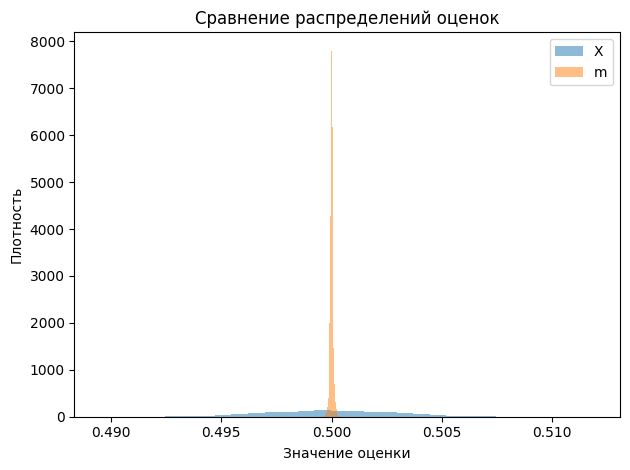

In [17]:
# Гистограммы
plt.hist(X_large, bins=30, alpha=0.5, label='X', density=True)
plt.hist(m_large, bins=30, alpha=0.5, label='m', density=True)
plt.title('Сравнение распределений оценок')
plt.xlabel('Значение оценки')
plt.ylabel('Плотность')
plt.legend()
plt.tight_layout()
plt.show()
# Выводы:
# 1) Обе оценки сходятся к 0.5 при увеличении n, значит состоятельны.
# 2) X несмещена, m тоже (средние близки к 0.5).
# 3) m имеет меньшую дисперсию, значит эффективнее. Это следует из меньшего разброса значений на графиках а также более узкого boxplot